In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr, pearsonr

data_dir = "db_29_3_text"
occ = pd.read_csv(os.path.join(data_dir, "Occupation Data.txt"), sep='\t', encoding='utf-8')
skills = pd.read_csv(os.path.join(data_dir, "Skills.txt"), sep='\t', encoding='utf-8')
abilities = pd.read_csv(os.path.join(data_dir, "Abilities.txt"), sep='\t', encoding='utf-8')
education = pd.read_csv(os.path.join(data_dir, "Education, Training, and Experience.txt"), sep='\t', encoding='utf-8')
rel = pd.read_csv(os.path.join(data_dir, "Related Occupations.txt"), sep='\t', encoding='utf-8')

In [21]:
# Skills
skills_lv = skills[skills['Scale ID'] == 'LV']
skills_im = skills[skills['Scale ID'] == 'IM']

# Abilities
abilities_lv = abilities[abilities['Scale ID'] == 'LV']
abilities_im = abilities[abilities['Scale ID'] == 'IM']

# Education: Endast RL (Required Level of Education)
edu_rl = education[education['Scale ID'] == 'RL']

# Pivot till matriser
lv_skill_matrix = skills_lv.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')
im_skill_matrix = skills_im.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')
lv_abil_matrix = abilities_lv.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')
im_abil_matrix = abilities_im.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')

# Education: Pivotera till (O*NET-SOC Code) x (RL-nivå 1–12)
edu_rl_matrix = edu_rl.pivot(index='O*NET-SOC Code', columns='Category', values='Data Value').fillna(0)

# Synka index: utgå alltid från IM-matriser
lv_skill_matrix = lv_skill_matrix.reindex(im_skill_matrix.index)
lv_abil_matrix = lv_abil_matrix.reindex(im_abil_matrix.index)

# (Valfritt) Om du vill köra PCA på domäner i exakt samma yrkesmängd:
common_codes = sorted(set(im_skill_matrix.index) & set(im_abil_matrix.index) & set(edu_rl_matrix.index))
im_skill_matrix = im_skill_matrix.loc[common_codes]
im_abil_matrix = im_abil_matrix.loc[common_codes]
edu_rl_matrix  = edu_rl_matrix.loc[common_codes]
lv_skill_matrix = lv_skill_matrix.loc[common_codes]
lv_abil_matrix = lv_abil_matrix.loc[common_codes]

edu_rl_matrix.to_csv('edu_rl_matrix_df.csv', index=True, header=True)



In [4]:
# PCA på skills (IM) – xi för ALLA domäner
pca = PCA(n_components=2)
coords = pca.fit_transform(im_skill_matrix.fillna(0).values)
xi_shared = np.arctan2(coords[:, 1], coords[:, 0]) % (2 * np.pi)

# Bygg om funktionen för att ta xi som parameter:
def build_domain_df(lv_matrix, im_matrix, occ, domain_name, xi):
    if im_matrix is None:  # Education
        data = lv_matrix.fillna(0).values
    else:
        data = im_matrix.fillna(0).values
    # xi är nu en parameter och används rakt av!
    if im_matrix is not None:
        lv_weighted = (lv_matrix * im_matrix).sum(axis=1) / im_matrix.sum(axis=1)
    else:
        levels = np.arange(1, lv_matrix.shape[1] + 1)
        lv_weighted = (lv_matrix.values * levels).sum(axis=1) / lv_matrix.sum(axis=1).values
        lv_weighted = pd.Series(lv_weighted, index=lv_matrix.index)
    chi = (lv_weighted - lv_weighted.min()) / (lv_weighted.max() - lv_weighted.min())
    occ_titles = occ.set_index('O*NET-SOC Code').reindex(lv_matrix.index)['Title']
    return pd.DataFrame({
        'onet_code': lv_matrix.index,
        'xi': xi,
        'chi': chi.values,
        'domain': domain_name,
        'title': occ_titles.values
    })

# Använd xi_shared för alla!
df_skills    = build_domain_df(lv_skill_matrix, im_skill_matrix, occ, 'Skills',    xi_shared)
df_abilities = build_domain_df(lv_abil_matrix, im_abil_matrix, occ, 'Abilities',   xi_shared)
df_education = build_domain_df(edu_rl_matrix, None,           occ, 'Education',   xi_shared)
df_plot = pd.concat([df_skills, df_abilities, df_education], ignore_index=True)


In [5]:
x = df_plot['chi'] * np.cos(df_plot['xi'])
y = df_plot['chi'] * np.sin(df_plot['xi'])
x_center = x.mean()
y_center = y.mean()
center_angle = np.arctan2(y_center, x_center) % (2 * np.pi)
df_plot['xi_rot'] = (df_plot['xi'] - center_angle) % (2 * np.pi)
df_skills['xi_rot'] = (df_skills['xi'] - center_angle) % (2 * np.pi)
df_abilities['xi_rot'] = (df_abilities['xi'] - center_angle) % (2 * np.pi)
df_education['xi_rot'] = (df_education['xi'] - center_angle) % (2 * np.pi)
print(f"Center angle: {np.degrees(center_angle):.2f} degrees")


Center angle: 157.07 degrees


8 [0.36274514 0.9203952 ]
27 [-0.93883453 -0.61037182]
9 [ 0.04158632 -0.81401807]
25 [-0.95804683 -0.96370652]
1 [ 0.15489304 -0.45984516]
17 [-0.95468823 -0.875148  ]


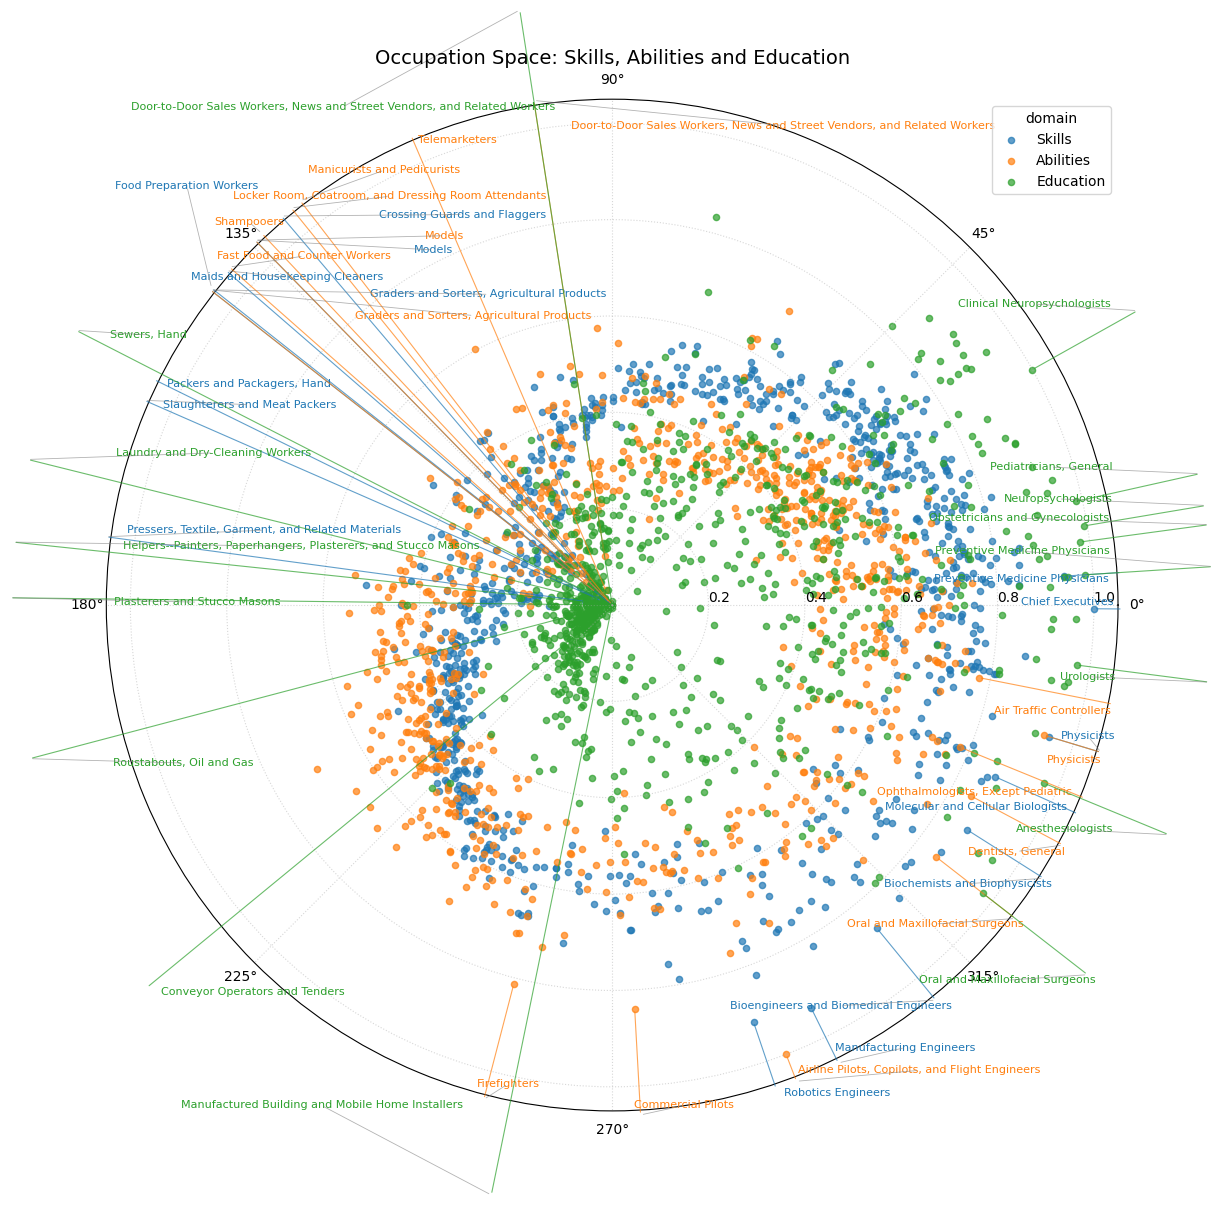

In [17]:
from adjustText import adjust_text 

def plot_occupation_space_domains(
    df,
    chi_col='chi',
    xi_col='xi_rot',
    domain_col='domain',
    color_map=None,
    annotate_n=8,
    figsize=(14,12),
    title=None,
    alpha=0.7
):
    unique_domains = df[domain_col].unique()
    if color_map is None:
        colors = plt.cm.tab10.colors
        color_map = {dom: colors[i % len(colors)] for i, dom in enumerate(unique_domains)}
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection':'polar'})
    for dom in unique_domains:
        mask = df[domain_col] == dom
        ax.scatter(df.loc[mask, xi_col], df.loc[mask, chi_col],
                   color=color_map[dom], alpha=alpha, s=20, label=dom)
    texts = []
    for dom in unique_domains:
        mask = df[domain_col] == dom
        sub = df.loc[mask]
        idx_max = sub[chi_col].nlargest(annotate_n).index
        idx_min = sub[chi_col].nsmallest(annotate_n).index
        idxs = pd.Index(idx_max.tolist() + idx_min.tolist()).unique()
        annots = sub.loc[idxs]

        # Sätt längre radie för etiketter för just Education
        if dom == 'Education':
            chi_label_dom = 1.25  # T ex 1.25 för Education
        else:
            chi_label_dom = 1.06  # Standard för övriga

        for _, row in annots.iterrows():
            angle = row[xi_col]
            # Bygg textobjekt och spara till texts-listan:
            txt = ax.text(
                angle, chi_label_dom,
                row.get('title', row.get('onet_code', '')),
                fontsize=8,
                ha='center', va='center',
                color=color_map[dom]
            )
            # Rita pil från label till punkt
            ax.annotate('', xy=(angle, row[chi_col]), xytext=(angle, chi_label_dom),
                        textcoords='data', arrowprops=dict(arrowstyle='-', lw=0.8, color=color_map[dom], alpha=0.7))
            texts.append(txt)

    # Justera etiketterna med adjustText (försök undvika överlapp)
    adjust_text(texts, ax=ax, expand_points=(2.8, 2.8), expand_text=(1.7, 1.7),
                force_text=2.5,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.6, alpha=0.6))

    ax.set_rlabel_position(0)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    ax.legend(loc='upper right', fontsize=10, title=domain_col)
    if title:
        ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig('occupation_space.svg', format='svg', bbox_inches='tight')
    plt.show()
    return fig, ax

# Plot
plot_occupation_space_domains(
    df_plot,
    chi_col='chi',
    xi_col='xi_rot',
    domain_col='domain',
    annotate_n=8,
    title='Occupation Space: Skills, Abilities and Education'
)
df_plot.to_csv('occupation_space_df.csv', index=False)


In [7]:
def ocs_near_correlation(df_domain, rel, domain_label):
    df_domain = df_domain.copy()
    df_domain['x'] = df_domain['chi'] * np.cos(df_domain['xi_rot'])
    df_domain['y'] = df_domain['chi'] * np.sin(df_domain['xi_rot'])
    code2xy = df_domain.set_index('onet_code')[['x', 'y']].to_dict('index')
    def occs_distance(row):
        code1 = row['O*NET-SOC Code']
        code2 = row['Related O*NET-SOC Code']
        xy1 = code2xy.get(code1)
        xy2 = code2xy.get(code2)
        if xy1 is not None and xy2 is not None:
            return np.sqrt((xy1['x'] - xy2['x'])**2 + (xy1['y'] - xy2['y'])**2)
        else:
            return np.nan
    rel[f'ocs_distance_{domain_label}'] = rel.apply(occs_distance, axis=1)
    coords = df_domain[['x', 'y']].values
    codes = df_domain['onet_code'].values
    dist_matrix = cdist(coords, coords)
    nearest_ranks = {}
    for i, code in enumerate(codes):
        dists = dist_matrix[i]
        sorted_indices = np.argsort(dists)
        sorted_codes = codes[sorted_indices]
        nearest_ranks[code] = {other_code: rank for rank, other_code in enumerate(sorted_codes)}
    rel[f'ocs_rank_{domain_label}'] = rel.apply(
        lambda row: nearest_ranks.get(row['O*NET-SOC Code'], {}).get(row['Related O*NET-SOC Code'], np.nan),
        axis=1
    )
    mask = rel[f'ocs_distance_{domain_label}'].notna() & rel[f'ocs_rank_{domain_label}'].notna()
    x = rel.loc[mask, f'ocs_rank_{domain_label}']
    y = rel.loc[mask, f'ocs_distance_{domain_label}']
    spearman = spearmanr(x, y)
    pearson = pearsonr(x, y)
    print(f"\n==== {domain_label} ====")
    print('Spearman rangkorrelation:', spearman)
    print('Pearson korrelation:', pearson)
    return rel

rel = ocs_near_correlation(df_skills, rel, 'skills')
rel = ocs_near_correlation(df_abilities, rel, 'abilities')
rel = ocs_near_correlation(df_education, rel, 'education')



==== skills ====
Spearman rangkorrelation: SignificanceResult(statistic=np.float64(0.9383289361308985), pvalue=np.float64(0.0))
Pearson korrelation: PearsonRResult(statistic=np.float64(0.9493754521522442), pvalue=np.float64(0.0))

==== abilities ====
Spearman rangkorrelation: SignificanceResult(statistic=np.float64(0.9393624824082977), pvalue=np.float64(0.0))
Pearson korrelation: PearsonRResult(statistic=np.float64(0.950141494552124), pvalue=np.float64(0.0))

==== education ====
Spearman rangkorrelation: SignificanceResult(statistic=np.float64(0.7071092337438558), pvalue=np.float64(0.0))
Pearson korrelation: PearsonRResult(statistic=np.float64(0.7882997933615219), pvalue=np.float64(0.0))


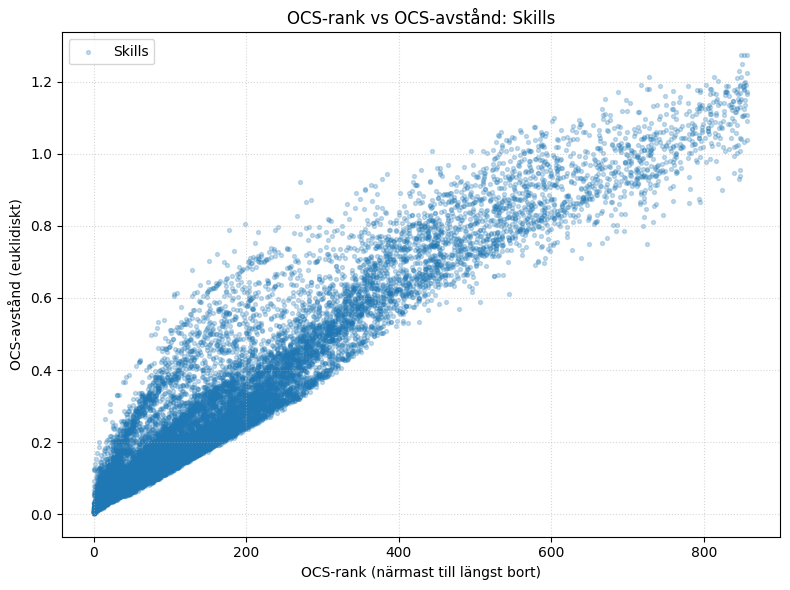

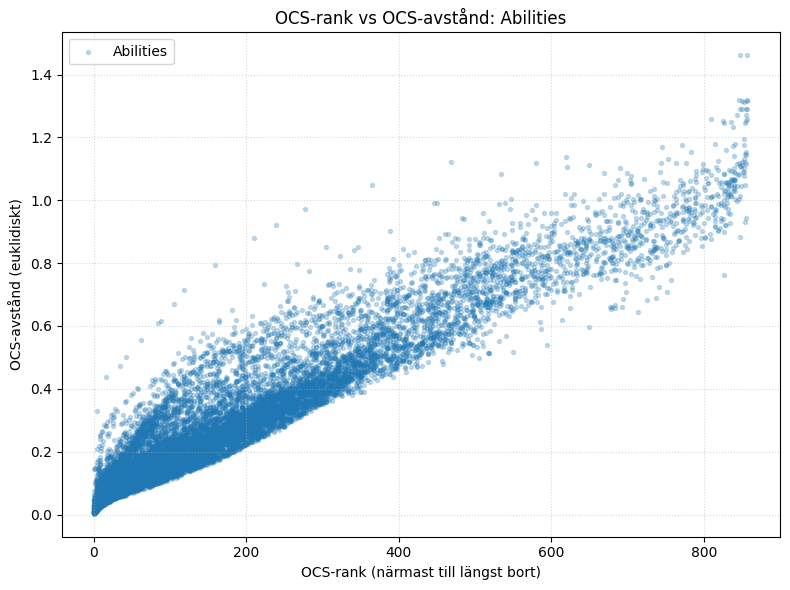

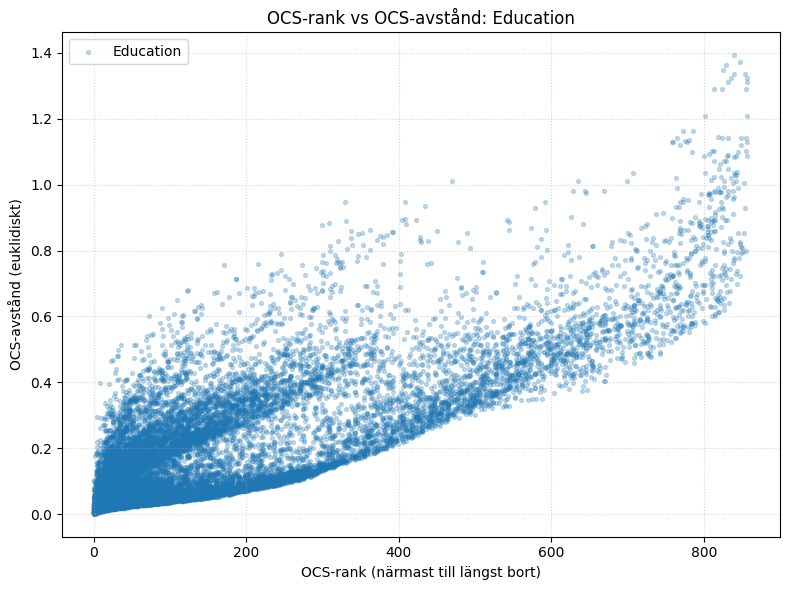

In [8]:
import matplotlib.pyplot as plt

def plot_ocs_rank_vs_distance(rel, domain_label, alpha=0.25):
    x = rel[f'ocs_rank_{domain_label}']
    y = rel[f'ocs_distance_{domain_label}']
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=alpha, s=8, label=domain_label.capitalize())
    plt.xlabel('OCS-rank (närmast till längst bort)')
    plt.ylabel('OCS-avstånd (euklidiskt)')
    plt.title(f'OCS-rank vs OCS-avstånd: {domain_label.capitalize()}')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Anropa för alla tre domäner:
for domain in ['skills', 'abilities', 'education']:
    plot_ocs_rank_vs_distance(rel, domain)
